# Data Exploration
Python notebook to get familiar with the data
</br>
</br>
Kerim Atak (kerim.atak@univie.ac.at)

## Raw Data

In [ ]:
import os
import pandas as pd
import numpy as np
import json
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import numpy as np
import json
import os

%load_ext autoreload
%autoreload 2

print("Current OS Path:", os.getcwd())

In [ ]:
data_session = "JPAS_0023_20230922"

In [ ]:
# import cluster_info.tsv
## contains information about each cluster (neuron), including quality metrics
## NOTE: This is what will be used to filter good units for NC-MCM/BunDLe-Net analysis
df = pd.read_csv(os.path.join(data_session, "cluster_info.tsv"), sep="\t")

# filter column "group" for value "good" to keep only good units
df = df[df["group"] == "good"]

print(df.head())
print("DataFrame Shape:", df.shape)

In [ ]:
# import channel_map.npy
## contains the mapping of channels to their physical locations on the probe ... probably
channel_map = np.load(os.path.join(data_session, "channel_map.npy"), allow_pickle=True)
print("Channel Map Shape:", channel_map.shape)
print("Channel Map Data:", channel_map)

In [ ]:
# import channel_positions.npy
## contains the physical positions of each channel on the probe ... probably
channel_positions = np.load(os.path.join(data_session, "channel_positions.npy"), allow_pickle=True)
print("Channel Positions Shape:", channel_positions.shape)
print("Channel Positions Data:", channel_positions)

In [ ]:
# import spike_times.npy
## contains the timestamps of each spike event of all neurons
## NOTE: This is what will be used for NC-MCM/BunDLe-Net analysis
## NOTE: spike_times, spike_clusters, and spike_templates are aligned by index
spike_times = np.load(os.path.join(data_session, "spike_times.npy"))
print("Spike times shape:", spike_times.shape)
print("First 10 spike times:", spike_times[:10])
print("First spike time:", np.min(spike_times))
print("Last spike time:", np.max(spike_times))

# plot histogramm of spike times
import plotly.express as px
fig = px.histogram(spike_times, nbins=100, title="Spike Times Histogram", labels={"value": "Time (samples)", "count": "Number of Spikes"})
fig.show()



In [ ]:
# import spike_clusters.npy
## assigns each spike to a cluster (neuron)
## NOTE: This is what will be used for NC-MCM/BunDLe-Net analysis
spike_clusters = np.load(os.path.join(data_session, "spike_clusters.npy"))
print("Spike clusters shape:", spike_clusters.shape)
print("First 10 spike clusters:", spike_clusters[:10])

In [ ]:
# import spike_templates.npy
## output file from Kilosort, assigns each spike to a template rather than a cluster (neuron), needs further processing/merging to get neuron assignments
spike_templates = np.load(os.path.join(data_session, "spike_templates.npy"))
print("Spike templates shape:", spike_templates.shape)
print("First 10 spike templates:", spike_templates[:10])

In [ ]:
# import spike_times_milliseconds_sync_to_behav_JPAS_0023_20230922.npy
## contains spike times in milliseconds, synchronized to behavioral data (the time values are the same as behavioral time values in metrics.json)
spike_times_ms_sync_to_behav = np.load(os.path.join(data_session, "spike_times_milliseconds_sync_to_behav.npy"))
print("Spike times ms shape:", spike_times_ms_sync_to_behav.shape)
print("First 10 spike times ms:", spike_times_ms_sync_to_behav[:10])

In [ ]:

translation_ms

In [ ]:
# Build full translation array via linear interpolation across the full index range


# Examples:
# array[4] == behavioral time at neuronal index 4 (exact if present, interpolated if not)
print("array[4] =", translation_ms[4])
print("array[5] =", translation_ms[5])

# Optional: function to map any neuronal index -> behavioral ms
def neuronal_to_ms(i: int) -> float:
    if i < 0 or i > max_idx:
        raise ValueError(f"Index {i} out of range [0, {max_idx}]")
    return float(translation_ms[i])

# Optional inverse mapping (behavioral ms -> neuronal index) via interpolation:
# Assumes ms_unique is strictly increasing. If not, consider monotonic regression or segment-wise handling.
def ms_to_neuronal(t_ms: float) -> float:
    return float(np.interp(t_ms, ms_unique, unique_idx))

# ...existing code...

In [ ]:
# import params.py, read as txt and print content
## contains metadata about the recording session
## parse n_channels_dat, offset, sample_rate, dtype, hp_filtered from params.py
## NOTE: Only sample_rate is interessting for now, which is 32050.755862876373 Hz
with open(os.path.join(data_session, "params.py"), "r") as f:
    params_content = f.read()
    print("Params.py content:\n", params_content)
    n_channels_dat = params_content.split("n_channels_dat = ")[1].split("\n")[0]
    offset = params_content.split("offset = ")[1].split("\n")[0]
    sample_rate = params_content.split("sample_rate = ")[1].split("\n")[0]
    dtype = params_content.split("dtype = '")[1].split("'")[0]
    hp_filtered = params_content.split("hp_filtered = ")[1].split("\n")[0]

print(f"n_channels_dat: {n_channels_dat}, offset: {offset}, sample_rate: {sample_rate}, dtype: {dtype}, hp_filtered: {hp_filtered}")

In [ ]:
# import metrics.json as dict and print keys
## contains various metrics about the recording session like 
with open(os.path.join(data_session, "metrics.json"), "r") as f:
    metrics = json.load(f)
    print("Metrics keys:", metrics.keys())

In [ ]:
def _metrics_json_overview(metrics_dict, showcase_num=5):
    # Print an overview of the metrics.json content
    for key, value in metrics_dict.items():
        print(f"{key}: {type(value)} - {value if isinstance(value, (int, float, str)) else '...'}")
        # if key is "metrics", print the keys inside metrics
        if key == "metrics":
            for metric_key in value.keys():
                print(f"  - {metric_key}")
    
    print()
    
    # experiment data
    print("="*15 + " Experiment Data " + "="*15)
    print(json.dumps(metrics_dict.get("experiment data", {}), indent=4))
    print() 
    
    # performance
    print("="*15 + " Performance " + "="*15)
    print(json.dumps(metrics_dict.get("performance", {}), indent=4))
    print()
    
    # metrics - blocks
    print("="*15 + " Metrics - Blocks " + "="*15)
    # num of blocks
    print("Number of blocks:", len(metrics_dict.get("metrics", {}).get("blocks", {})))
    print(json.dumps(metrics_dict.get("metrics", {}).get("blocks", {}), indent=4))
    print() 
    
    # metrics - trials
    print("="*15 + " Metrics - Trials " + "="*15)
    # num of trials
    trials = metrics_dict.get("metrics", {}).get("trials", [])
    print("Number of trials:", len(trials))
    print(f"First {showcase_num} trials:")
    print(json.dumps(trials[:showcase_num], indent=4))  # Print only the first 5 trials
    print("...")
    
    # metrics - states
    print("="*15 + " Metrics - States " + "="*15)
    states = metrics_dict.get("metrics", {}).get("states", [])
    print("Number of states:", len(states))
    print(json.dumps(states[:showcase_num], indent=4))  # Print only the
    print("...")
    
    # kayeton cam (t ms/#frame/vid time)
    print("="*15 + " Kayeton Cam Data " + "="*15)
    kayeton_cam = metrics_dict.get("kayeton cam (t ms/#frame/vid time)", {})
    print("Number of kayeton cam entries:", len(kayeton_cam))
    # compute average t ms using the first element of each kayeton_cam entry
    t_ms_vals = []
    for entry in kayeton_cam:
        t_ms_vals.append(float(entry[0]))
    intervals = np.diff(t_ms_vals)
    mean_interval = float(np.mean(intervals))
    std_interval = float(np.std(intervals))
    print(f"Average interval between consecutive 't ms': {mean_interval:.3f} ms (±{std_interval:.3f} ms std)")
    print(json.dumps(kayeton_cam[:showcase_num], indent=4))
    print("...")
    
    # wheel
    print("="*15 + " Wheel Data " + "="*15)
    wheel = metrics_dict.get("wheel", {})
    print("Number of wheel entries:", len(wheel))
    print(json.dumps(wheel[:showcase_num], indent=4))
    print("...")

    # clock 100ms
    print("="*15 + " Clock 100ms Data " + "="*15)
    clock_100ms = metrics_dict.get("clock 100ms", {})
    print("Number of clock 100ms entries:", len(clock_100ms))
    print(json.dumps(clock_100ms[:showcase_num], indent=4))
    print("...")
    
    # clock 5min
    print("="*15 + " Clock 5min Data " + "="*15)
    clock_5min = metrics_dict.get("clock 5min", {})
    print("Number of clock 5min entries:", len(clock_5min))
    print(json.dumps(clock_5min[:showcase_num], indent=4))
    print("...")
    
    
_metrics_json_overview(metrics)

In [ ]:
# Load data
with open(os.path.join(data_session, 'metrics.json'), 'r') as f:
    data = json.load(f)

trials = data['metrics']['trials']
blocks = data['metrics']['blocks']
states = data['metrics'].get('states', [])  # Get states, default to empty list if not present

print("\nNumber of trials:", len(trials))
print("Number of states:", len(states))

# Check for missing 'choice' keys
missing_choice = [i for i, t in enumerate(trials) if 'choice' not in t]
print(f"\nTrials missing 'choice': {len(missing_choice)}")

# Analyze states
if states:
    unique_states = list(set([state[1] for state in states]))
    print(f"Unique states: {unique_states}")
else:
    unique_states = []
    print("No states data found in the file")

# Create figure with 3 subplots (adding states plot in middle)
fig = make_subplots(
    rows=3, cols=1,
    row_heights=[0.4, 0.2, 0.4],  # Adjusted heights
    vertical_spacing=0.08,
    subplot_titles=('Trial-by-Trial Choices (Click on a trial to see timing)', 
                    'States Over Time',
                    'Moving Average: Left Choice Rate')
)

# ========================================================================
# PLOT 1: Trial-by-trial choices (top)
# ========================================================================
for i, trial in enumerate(trials):
    x_time = trial.get('start', i)
    
    if 'choice' not in trial:
        marker_symbol = 'circle'
        y = 0.5
        color = 'gray'
        hover_text = f'<b>Trial: {i}</b><br>Time: {x_time}<br>No choice recorded'
    else:
        if trial['choice'] == 'r':
            marker_symbol = 'triangle-up'
            y = 0
        else:
            marker_symbol = 'triangle-down'
            y = 1
        
        color = 'blue' if trial.get('rewarded', False) else 'red'
        
        prob_lr = trial.get('set reward probabs l/r', [None, None])
        hover_text = f"""<b>Trial: {i} - Click to view timing</b><br>
<br><b>Timing:</b><br>
Start: {trial.get('start', 'N/A')}<br>
Hold start: {trial.get('hold_start', 'N/A')}<br>
T choosing: {trial.get('t choosing', 'N/A')}<br>
T chosen: {trial.get('t chosen', 'N/A')}<br>
<br><b>Choice & Outcome:</b><br>
Choice: {trial.get('choice', 'N/A')}<br>
Rewarded: {trial.get('rewarded', 'N/A')}<br>
<br><b>Block Info:</b><br>
Reward prob L/R: [{prob_lr[0]:.3f}, {prob_lr[1]:.3f}]<br>
Achievement reached: {trial.get('Achievement reached', 'N/A')}<br>
<br><b>Recent Performance:</b><br>
Reward rate recent: {trial.get('reward rate recent', 'N/A')}<br>
Rew rate recent rights: {trial.get('rew rate in recent rights', 'N/A')}<br>
Rew rate recent lefts: {trial.get('rew rate in recent lefts', 'N/A')}
"""
    
    fig.add_trace(go.Scatter(
        x=[x_time],
        y=[y],
        mode='markers',
        marker=dict(
            symbol=marker_symbol,
            size=8,
            color=color,
            line=dict(width=0.5, color='white')
        ),
        customdata=[[i, trial.get('start', 0), trial.get('hold_start', 0), 
                     trial.get('t choosing', 0), trial.get('t chosen', 0),
                     trial.get('choice', ''), trial.get('rewarded', False)]],
        showlegend=False,
        hovertemplate=hover_text + '<extra></extra>',
        name=f'trial_{i}'
    ), row=1, col=1)

# Add placeholder for connecting line
fig.add_trace(go.Scatter(
    x=[],
    y=[],
    mode='lines',
    line=dict(color='darkgray', width=3, dash='solid'),
    showlegend=False,
    name='timing_line'
), row=1, col=1)

# Add placeholders for timing markers (will be updated via JavaScript)
for timing_type in ['start_marker', 'hold_marker', 'choosing_marker', 'chosen_marker']:
    fig.add_trace(go.Scatter(
        x=[],
        y=[],
        mode='markers+text',
        marker=dict(size=15, line=dict(width=2, color='white')),
        textposition='top center',
        showlegend=False,
        name=timing_type
    ), row=1, col=1)

# ========================================================================
# PLOT 2: States visualization (middle) - NEW!
# ========================================================================
if states and len(states) > 0:
    # Define colors for different states - aligned with trial plot colors
    state_colors = {
        'waiting': 'white',             # Pure white
        'hold': 'orange',               # Orange (matches hold marker in first plot)
        'choosing': 'cyan',             # Cyan (matches choosing marker in first plot)
        'reward': 'blue',               # Blue (matches rewarded trials in first plot)
        'no reward': 'red',             # Red (matches unrewarded trials in first plot)
        'intertrial': 'gray',           # Gray
        'delay': 'lightgray',           # Light gray
    }
    
    # Add a color for any unknown states
    for state in unique_states:
        if state not in state_colors:
            state_colors[state] = '#CCCCCC'  # Gray for unknown states
    
    # Sort states by timestamp to ensure correct ordering
    states_sorted = sorted(states, key=lambda x: x[0])
    
    # Create state timeline visualization
    for i, (timestamp, state_name) in enumerate(states_sorted):
        # Determine the duration of this state
        if i < len(states) - 1:
            next_timestamp = states_sorted[i + 1][0]
            duration = next_timestamp - timestamp
        else:
            # For the last state, use a default duration or find the session end
            duration = 1
        
        # Determine border color - use darker version of fill color, or black for white
        fill_color = state_colors.get(state_name, '#CCCCCC')
        if fill_color == 'white':
            border_color = 'darkgray'
        else:
            border_color = fill_color
        
        # Add rectangle for state duration with visible border
        fig.add_trace(go.Scatter(
            x=[timestamp, timestamp + duration, timestamp + duration, timestamp, timestamp],
            y=[0, 0, 1, 1, 0],
            fill='toself',
            fillcolor=fill_color,
            line=dict(color=border_color, width=1),
            mode='lines',
            showlegend=False,
            hoverinfo='text',  # Changed from hovertemplate to hoverinfo
            text=f"<b>State: {state_name}</b><br>Start: {timestamp}<br>Duration: {duration} samples <br>End: {timestamp + duration}<br>Index: {i} of {len(states_sorted)}",
            name=f'state_{i}'
        ), row=2, col=1)
    
    # Add legend for states
    legend_added = set()
    for state in unique_states:
        if state not in legend_added:
            fig.add_trace(go.Scatter(
                x=[None],
                y=[None],
                mode='markers',
                marker=dict(size=15, color=state_colors.get(state, '#CCCCCC'), symbol='square'),
                name=f'State: {state}',
                legendgroup='states',
                showlegend=True
            ), row=2, col=1)
            legend_added.add(state)

else:
    # Add placeholder text when no states data
    fig.add_annotation(
        text="No states data available",
        x=0.5,
        y=0.5,
        xref="x2",
        yref="y2",
        showarrow=False,
        font=dict(size=16, color="gray"),
        row=2, col=1
    )

# ========================================================================
# PLOT 3: Moving average of left choices (bottom, previously plot 2)
# ========================================================================
window = 10
valid_trials_with_choice = [t for t in trials if 'choice' in t]
times = [t.get('start', 0) for t in valid_trials_with_choice]
choices = [1 if t['choice'] == 'l' else 0 for t in valid_trials_with_choice]

left_choice_rate = np.convolve(choices, np.ones(window)/window, mode='valid')
times_ma = times[window-1:]

fig.add_trace(go.Scatter(
    x=times_ma,
    y=left_choice_rate,
    mode='lines',
    line=dict(color='purple', width=2),
    name=f'Left choice rate (window={window})',
    hovertemplate='Time: %{x}<br>Left choice rate: %{y:.2f}<extra></extra>',
    legendgroup='behavior'
), row=3, col=1)

fig.add_hline(y=0.5, line=dict(color='gray', dash='dash'), row=3, col=1)

# ========================================================================
# Add block boundaries to all plots
# ========================================================================
for j, block in enumerate(blocks):
    block_time = block.get('t', 0)
    
    if j < len(blocks) - 1:
        next_block_time = blocks[j + 1].get('t', float('inf'))
    else:
        next_block_time = float('inf')
    
    trials_in_block = [t for t in trials if block_time <= t.get('start', 0) < next_block_time]
    n_trials = len(trials_in_block)
    
    if 'probabilities l/r' in block:
        prob_lr = block.get('probabilities l/r', [None, None])
        block_hover = f"""<b>Block {j}: {block.get('block', 'Unknown')}</b><br>
<br><b>Block Start:</b><br>
Time: {block_time}<br>
<br><b>Trials in Block:</b><br>
Number of trials: {n_trials}<br>
<br><b>Reward Probabilities:</b><br>
Left: {prob_lr[0]:.3f}<br>
Right: {prob_lr[1]:.3f}<br>
<br><b>Transition Criteria:</b><br>
Performance: {block.get('block transition perf criteria', 'N/A')}"""
        
        for row in [1, 2, 3]:
            fig.add_trace(go.Scatter(
                x=[block_time],
                y=[0.5],
                mode='markers',
                marker=dict(size=20, color='green', opacity=0, line=dict(width=0)),
                showlegend=False,
                hovertemplate=block_hover + '<extra></extra>',
                legendgroup='blocks'
            ), row=row, col=1)
        
        for row in [1, 2, 3]:
            fig.add_vline(x=block_time, line=dict(color='green', dash='dash', width=2), opacity=0.5, row=row, col=1)
        
    else:
        block_hover = f"""<b>Block {j}: {block.get('block', 'Unknown')}</b><br>
<br><b>Block Start:</b><br>
Time: {block_time}<br>
<br><b>Trials in Block:</b><br>
Number of trials: {n_trials}<br>
<br>No reward probabilities (non-task block)"""
        
        for row in [1, 2, 3]:
            fig.add_trace(go.Scatter(
                x=[block_time],
                y=[0.5],
                mode='markers',
                marker=dict(size=20, color='orange', opacity=0, line=dict(width=0)),
                showlegend=False,
                hovertemplate=block_hover + '<extra></extra>',
                legendgroup='blocks'
            ), row=row, col=1)
        
        for row in [1, 2, 3]:
            fig.add_vline(x=block_time, line=dict(color='orange', dash='dash', width=2), opacity=0.5, row=row, col=1)

# ========================================================================
# Update layout
# ========================================================================
fig.update_xaxes(title_text="Time (samples)", matches='x', row=3, col=1)
fig.update_xaxes(showgrid=True, gridwidth=1, gridcolor='lightgray', matches='x', row=1, col=1)
fig.update_xaxes(showgrid=True, gridwidth=1, gridcolor='lightgray', matches='x', row=2, col=1)

# Plot 1 (Trials)
fig.update_yaxes(
    title_text="Choice",
    tickmode='array',
    tickvals=[0, 0.5, 1],
    ticktext=['Right', 'No Choice', 'Left'],
    range=[-0.1, 1.1],
    showgrid=True,
    gridwidth=1,
    gridcolor='lightgray',
    row=1, col=1
)

# Plot 2 (States) 
fig.update_yaxes(
    title_text="States",
    tickmode='array',
    tickvals=[0, 0.5, 1],
    ticktext=['', 'Behavioral State', ''],
    range=[-0.1, 1.1],
    showgrid=False,
    row=2, col=1
)

# Plot 3 (Choice rate)
fig.update_yaxes(
    title_text="Choice Rate",
    tickmode='array',
    tickvals=[0, 0.5, 1],
    ticktext=['Right', 'Equal', 'Left'],
    range=[0, 1],
    showgrid=True,
    gridwidth=1,
    gridcolor='lightgray',
    row=3, col=1
)

fig.update_layout(
    title=f'Session Overview: {len(trials)} Trials, {len(states)} States<br><sub>Blue=Rewarded, Red=Unrewarded, Gray=No Choice | Green=Task blocks, Orange=Non-task blocks</sub>',
    width=1400,
    height=1000,  # Increased height for 3 plots
    hovermode='closest',
    plot_bgcolor='rgba(240,240,240,0.5)',
    showlegend=True,
    legend=dict(
        orientation="h",
        yanchor="bottom",
        y=1.02,
        xanchor="right",
        x=1
    )
)

# Write to HTML with custom JavaScript (updated for 3 plots)
html_string = fig.to_html(include_plotlyjs='cdn')

# Insert custom JavaScript before </body> (updated trace indices for 3 plots)
custom_js = """
<script>
var plot = document.getElementsByClassName('plotly-graph-div')[0];
var lastSelectedTrial = null;

plot.on('plotly_click', function(data){
    var point = data.points[0];
    
    // Check if click is from a trial point (has customdata)
    if (point.data.customdata && point.data.customdata[point.pointIndex]) {
        var customData = point.data.customdata[point.pointIndex];
        var trialIdx = customData[0];
        var start = customData[1];
        var holdStart = customData[2];
        var tChoosing = customData[3];
        var tChosen = customData[4];
        var choice = customData[5];
        var rewarded = customData[6];
        
        // If clicking the same trial, remove markers
        if (lastSelectedTrial === trialIdx) {
            // Clear connecting line
            var lineUpdate = {
                x: [[]],
                y: [[]]
            };
            var numTrials = """ + str(len(trials)) + """;
            Plotly.restyle(plot, lineUpdate, [numTrials]);
            
            // Clear all timing markers
            var update = {
                x: [[], [], [], []],
                y: [[], [], [], []],
                text: [[], [], [], []],
                'marker.color': [[], [], [], []],
                'marker.symbol': [[], [], [], []]
            };
            
            var markerIndices = [numTrials+1, numTrials+2, numTrials+3, numTrials+4];
            Plotly.restyle(plot, update, markerIndices);
            
            lastSelectedTrial = null;
            return;
        }
        
        lastSelectedTrial = trialIdx;
        
        // Determine y position based on choice
        var yPos = (choice === 'r') ? 0 : 1;
        
        // Update connecting line first
        var lineUpdate = {
            x: [[start, holdStart, tChoosing, tChosen]],
            y: [[yPos, yPos, yPos, yPos]]
        };
        var numTrials = """ + str(len(trials)) + """;
        Plotly.restyle(plot, lineUpdate, [numTrials]);
        
        // Prepare timing markers data
        var timingData = [
            {x: [start], y: [yPos], text: ['Start'], color: 'green', symbol: 'square'},
            {x: [holdStart], y: [yPos], text: ['Hold'], color: 'orange', symbol: 'diamond'},
            {x: [tChoosing], y: [yPos], text: ['Go!'], color: 'cyan', symbol: 'star'},
            {x: [tChosen], y: [yPos], text: ['Done'], color: 'magenta', symbol: 'x'}
        ];
        
        // Update each timing marker trace
        for (var i = 0; i < 4; i++) {
            var update = {
                x: [timingData[i].x],
                y: [timingData[i].y],
                text: [timingData[i].text],
                'marker.color': [[timingData[i].color]],
                'marker.symbol': [[timingData[i].symbol]]
            };
            Plotly.restyle(plot, update, [numTrials + 1 + i]);
        }
        
        // Zoom to trial region
        var margin = (tChosen - start) * 1.5;
        var layoutUpdate = {
            'xaxis.range': [start - margin, tChosen + margin]
        };
        Plotly.relayout(plot, layoutUpdate);
    }
});

// Double-click to reset zoom
plot.on('plotly_doubleclick', function(){
    Plotly.relayout(plot, {
        'xaxis.autorange': true,
        'xaxis2.autorange': true,
        'xaxis3.autorange': true
    });
    
    var numTrials = """ + str(len(trials)) + """;
    
    // Clear connecting line
    var lineUpdate = {
        x: [[]],
        y: [[]]
    };
    Plotly.restyle(plot, lineUpdate, [numTrials]);
    
    // Clear timing markers
    var update = {
        x: [[], [], [], []],
        y: [[], [], [], []],
        text: [[], [], [], []],
        'marker.color': [[], [], [], []],
        'marker.symbol': [[], [], [], []]
    };
    var markerIndices = [numTrials+1, numTrials+2, numTrials+3, numTrials+4];
    Plotly.restyle(plot, update, markerIndices);
    
    lastSelectedTrial = null;
});
</script>
"""

# Insert the custom JS before </body>
html_string = html_string.replace('</body>', custom_js + '</body>')

# Save to file
with open('interactive_trial_plot.html', 'w', encoding='utf-8') as f:
    f.write(html_string)

print("\n✓ Enhanced interactive plot saved to 'enhanced_interactive_trial_plot.html'")
print("Instructions:")
print("  - Click on any trial to see timing markers with connecting line and zoom")
print("  - Click the same trial again to hide markers")
print("  - Double-click anywhere to reset zoom")
print("  - States are visualized as colored rectangles in the middle plot")
print("  - Hover over states to see detailed information")

# Print summary statistics
valid_trials = [t for t in trials if 'choice' in t and 'rewarded' in t]
choices_summary = [0 if t['choice'] == 'r' else 1 for t in valid_trials]
rewards = [1 if t['rewarded'] else 0 for t in valid_trials]

print("\n" + "="*50)
print("SESSION SUMMARY")
print("="*50)
print(f"Total trials: {len(trials)}")
print(f"Trials with no choice: {len(missing_choice)}")
print(f"Valid trials with choice: {len(valid_trials)}")
print(f"Right choices: {choices_summary.count(0)} ({choices_summary.count(0)/len(choices_summary)*100:.1f}%)")
print(f"Left choices: {choices_summary.count(1)} ({choices_summary.count(1)/len(choices_summary)*100:.1f}%)")
print(f"Rewarded trials: {rewards.count(1)} ({rewards.count(1)/len(rewards)*100:.1f}%)")
print(f"Unrewarded trials: {rewards.count(0)} ({rewards.count(0)/len(rewards)*100:.1f}%)")
print(f"Total states: {len(states)}")
if unique_states:
    print(f"Unique states: {', '.join(unique_states)}")

## Processed Data

In [ ]:
from dataset import BanditTaskNeuroPixelsDataset
import plotly.graph_objects as go
import os
import numpy as np

%load_ext autoreload
%autoreload 2

# go to folder <
old_path = os.getcwd()
os.chdir('/home/kerim/Projects/Neural Algorithms/NC-MCM/')
from ncmcm.visualisers.neuronal_behavioural import plotting_neuronal_behavioural
os.chdir(old_path)

print("Current OS Path:", os.getcwd())

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Current OS Path: /home/kerim/Projects/Neural Algorithms/NC-MCM/datasets/raw/2arm_bandit_data


In [13]:
ds = BanditTaskNeuroPixelsDataset(data_path="JPAS_0023_20230922", downsample_num_samples=50000)

In [14]:
print("Frequency: ", ds.fs)
print("Recording in mins: ", ds.x.shape[1] / ds.fs / 60)

Frequency:  35.714290655450164
Recording in mins:  21.552997018086725


In [15]:
ds.x

<Compressed Sparse Row sparse matrix of dtype 'uint8'
	with 2405918 stored elements and shape (367, 46185)>

In [16]:
ds.b

array([0, 0, 0, ..., 3, 3, 3], shape=(46185,), dtype=int8)

In [17]:
np.unique(ds.b)

array([0, 1, 2, 3, 4, 5], dtype=int8)

In [18]:
ds.b_labels_dict

{0: 'intertrial',
 1: 'hold',
 2: 'reward',
 3: 'no reward',
 4: 'choosing left',
 5: 'choosing right'}

In [19]:
# Get unique elements and their counts
unique_elements, counts = np.unique(ds.b, return_counts=True)

# Map unique elements to their labels using ds.b_labels_dict
labels = [ds.b_labels_dict.get(element, str(element)) for element in unique_elements]

# Create the bar chart
fig = go.Figure(data=[
    go.Bar(
        x=labels,
        y=counts / ds.b.shape[0],
        text=[f"{count/ds.b.shape[0]:.2%} ({count})" for count in counts],
        textposition='auto'
    )
])

# Update layout
fig.update_layout(
    title="Bar Chart of ds.b Elements",
    xaxis_title="Labels",
    yaxis_title="Frequency",
    yaxis=dict(range=[0, 0.8]),
    template="plotly_white"
)

# Show the plot
fig.show()

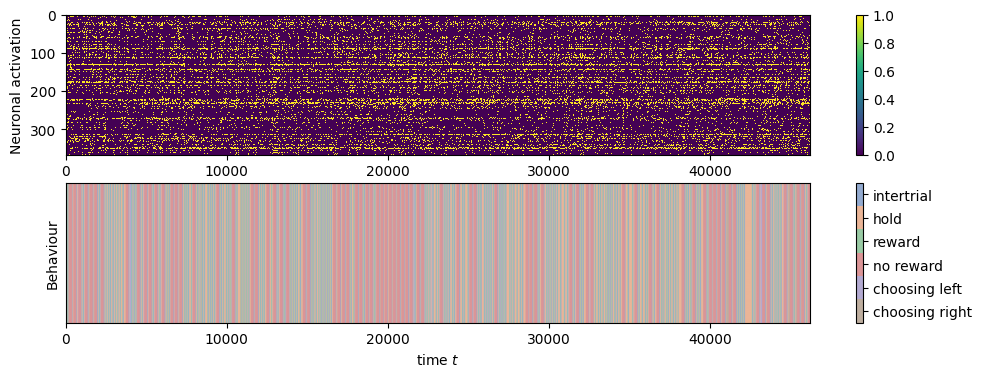

In [20]:
_ = plotting_neuronal_behavioural(ds.x.T.toarray(), ds.b, b_names=list(ds.b_labels_dict.values()))